In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import pickle

In [2]:

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_censored'
g_resol = 1
model_prefix = 'Joint'

DIR_MODEL_SAVE = os.path.join('sksurv_models/more_g', project, model_prefix)

if os.path.exists(DIR_MODEL_SAVE):
    shutil.rmtree(DIR_MODEL_SAVE)
    os.mkdir(DIR_MODEL_SAVE)
else:
    os.mkdir(DIR_MODEL_SAVE)

In [3]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_train = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='train', 
    mode='first_cross_obs_only_more_g', 
    separate_g_from_feats=False
)
ds_val = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='val', 
    mode='first_cross_obs_only_more_g', 
    separate_g_from_feats=False
)


In [4]:
df_Xy_train = ds_train._get_df_Xy_trans_obs_more_g()

assert all(
    df_Xy_train.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_train['event_observed'] = df_Xy_train['event_observed'].astype(bool)
df_Xy_train = df_Xy_train.sort_values('subject')

df_Xy_val = ds_val._get_df_Xy_trans_obs_more_g()
assert all(
    df_Xy_val.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_val = df_Xy_val.sort_values('subject')
df_Xy_val['event_observed'] = df_Xy_val['event_observed'].astype(bool)

df_Xy_val_grid = ds_val._get_df_Xy_trans_obs_more_g()
df_Xy_val_grid = df_Xy_val_grid.sort_values(['subject',ds_train.colname_g])

df_Xy_val_grid['event_observed'] = df_Xy_val_grid['event_observed'].astype(bool)


In [5]:
df_Xy_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,False,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,0,False,8,2.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
2,0,False,8,3.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
3,0,False,8,4.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
4,4,True,4,3.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1


In [6]:
cols_y = ['event_observed', 'duration']
cols_X = np.r_[[ds_train.colname_g], df_Xy_train.columns[df_Xy_train.columns.str.startswith('feat')]]

In [7]:
cols_y

['event_observed', 'duration']

In [8]:
cols_X

array(['g_max_by_time', 'feat00', 'feat01', 'feat02', 'feat03', 'feat04',
       'feat05', 'feat06', 'feat07', 'feat08', 'feat09', 'feat10',
       'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16',
       'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22',
       'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28',
       'feat29', 'feat30', 'feat31'], dtype=object)

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
def get_non_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(n_jobs=n_jobs, random_state=random_state, min_samples_leaf=3, n_estimators=1000)
        except TypeError:
            return model_class(random_state=random_state, min_samples_leaf=10, n_estimators=50)
    return get_model

def get_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(fit_baseline_model=True, ties='efron')
        except TypeError:
            try:
                return model_class(fit_baseline_model=True)
            except TypeError:
                return model_class()
    return get_model

model_name_to_class = {
    f'{model_prefix}_{GradientBoostingSurvivalAnalysis.__name__}':get_non_cox_model(GradientBoostingSurvivalAnalysis),
    f'{model_prefix}_{RandomSurvivalForest.__name__}':get_non_cox_model(RandomSurvivalForest),
}

In [10]:
df_metrics = []
surv_funcs = dict()
event_to_model = dict()
seeds = [10,20,30,40,50]
for model_name, model_class in model_name_to_class.items():
    for seed in seeds:
        model_id = f'{model_name}_more_g_seed_{seed}'
        model = model_class(n_jobs=-1, random_state=seed)
        y = df_Xy_train[cols_y].to_records(index=False)
        X = df_Xy_train[cols_X]
        model.fit(X, y)

        model_path = os.path.join(DIR_MODEL_SAVE,f'{model_id}.pickle')
        with open(model_path, 'wb') as f:
            # Pickle the 'data' dictionary using the highest protocol available.
            pickle.dump(model, f)

        for g, df_train_sub in df_Xy_train.groupby(ds_train.colname_g):
            if all(df_train_sub['event_observed'] == 0):
                continue
            
            y = df_train_sub[cols_y].to_records(index=False)
            X = df_train_sub[cols_X]
            event_to_model[f'{model_id}_event_{g}'] = model
            record = {
                'model_name':model_name,
                'event':g,
                'seed':seed,
                'c_index_train':model.score(X,y)
            }

            df_val_sub = df_Xy_val.loc[
                df_Xy_val[ds_train.colname_g] == g,:
            ]
            y = df_val_sub[cols_y].to_records(index=False)
            X = df_val_sub[cols_X]
            record['c_index_val'] = model.score(X,y)
            df_metrics.append(record)

            df_val_sub = df_Xy_val_grid.loc[
                df_Xy_val_grid[ds_train.colname_g] == g,:
            ].drop(columns=['duration','event_observed']).drop_duplicates().sort_values('subject')
            X = df_val_sub[cols_X]

            surv_funcs[f'{model_id}_event_{g}'] = model.predict_survival_function(X=X)
        print(f'finished running model {model_name}')
df_metrics = pd.DataFrame(df_metrics)


finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest


In [11]:
df_val_sub

,subject,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,feat06,feat07,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
14,18,5.0,0.704272,-0.820974,-0.175555,1.109713,0.091841,-0.194910,-0.365020,-0.301989,...,2.344199,0.458714,-2.766334,0.205854,1.171364,-1.175700,-0.128304,0.0,1,1
208,405,5.0,0.163817,0.067288,0.999017,0.446789,0.977083,-0.400258,0.155375,-0.822591,...,-0.677664,0.493838,1.426052,2.042874,0.159796,0.762908,1.161438,1.0,1,1
245,451,5.0,-0.608491,-0.538549,0.627780,-1.062064,0.238077,0.442120,-1.050648,0.459236,...,1.592896,-0.886518,1.407962,-0.215863,1.092778,-2.326384,-0.193926,1.0,1,1
276,529,5.0,-0.422492,-0.190714,0.863647,-0.009993,1.228311,-0.726036,0.236991,-0.195743,...,1.299456,-0.033270,-1.405113,0.588211,0.823490,0.276499,-1.838235,0.0,1,1
344,679,5.0,-1.891535,-1.103721,-0.401995,0.340238,0.630697,-1.051464,0.392522,1.426847,...,0.563015,0.097500,-0.517288,-0.144124,-0.139884,-0.762510,1.985727,0.0,1,1
440,899,5.0,-0.590194,-0.157154,1.038797,-1.069174,1.594122,-0.124055,-1.130820,-0.401447,...,0.069255,-1.331647,-0.247609,-1.019994,-0.148073,-0.470155,-1.095707,0.0,1,1
1125,2294,5.0,-0.381003,-0.115894,0.527255,-0.230139,-0.069532,0.816477,-0.136845,1.028037,...,0.547067,0.288821,0.209421,2.308115,-0.235940,1.448309,-0.201114,0.0,1,1
1374,2853,5.0,2.540136,0.955480,1.114306,1.366285,-0.867567,-0.080487,0.539489,0.150279,...,0.788939,1.052017,0.837595,0.265115,0.672041,-0.070620,-0.513706,0.0,1,1
1479,3110,5.0,1.141678,1.690006,-0.072638,0.203598,-0.246928,0.558304,-2.205868,-1.382900,...,1.084066,1.536071,0.562881,-0.232326,-1.445086,-0.611672,0.885417,1.0,1,1
1540,3269,5.0,1.106209,0.791514,-0.096815,-0.214086,-1.928544,-0.428564,-0.954627,-0.161312,...,-0.522825,0.909931,-0.164704,0.179663,-0.527907,-0.006008,1.335035,0.0,1,1


In [12]:
df_metrics.groupby(['model_name','event'])['c_index_val'].describe()

count      mean       std  \
model_name                             event                              
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.632163  0.000000   
                                       2.0      5.0  0.697840  0.000000   
                                       3.0      5.0  0.618620  0.000000   
                                       4.0      5.0  0.582596  0.000000   
                                       5.0      5.0  0.500000  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.708943  0.002525   
                                       2.0      5.0  0.771336  0.003072   
                                       3.0      5.0  0.702015  0.004187   
                                       4.0      5.0  0.659036  0.007019   
                                       5.0      5.0  0.522388  0.021108   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_GradientBoostingSurvivalAnalysis 1.0    0.632163  0.632163  0.632163   
                                       2.0    0.697840  0.697840  0.697840   
                                       3.0    0.618620  0.618620  0.618620   
                                       4.0    0.582596  0.582596  0.582596   
                                       5.0    0.500000  0.500000  0.500000   
Joint_RandomSurvivalForest             1.0    0.706040  0.707716  0.708902   
                                       2.0    0.767428  0.769157  0.771517   
                                       3.0    0.694907  0.702751  0.703073   
                                       4.0    0.649673  0.653585  0.662050   
                                       5.0    0.507463  0.507463  0.507463   

                                                   75%       max  
model_name                             event                      
Joint_GradientBoostingSurvivalAnalysis 1.0    0.632163  0.632163  
                                       2.0    0.697840  0.697840  
                                       3.0    0.618620  0.618620  
                                       4.0    0.582596  0.582596  
                                       5.0    0.500000  0.500000  
Joint_RandomSurvivalForest             1.0    0.709177  0.712881  
                                       2.0    0.773932  0.774646  
                                       3.0    0.703288  0.706055  
                                       4.0    0.664230  0.665641  
                                       5.0    0.537313  0.552239

In [13]:
df = df_metrics.copy()
df['val_as_frac_of_train'] = df_metrics['c_index_val']/df_metrics['c_index_train']
df.groupby(['model_name','event'])['val_as_frac_of_train'].describe()

count      mean           std  \
model_name                             event                                  
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.821920  0.000000e+00   
                                       2.0      5.0  0.923322  1.241267e-16   
                                       3.0      5.0  0.844373  0.000000e+00   
                                       4.0      5.0  0.793601  0.000000e+00   
                                       5.0      5.0  1.043417  0.000000e+00   
Joint_RandomSurvivalForest             1.0      5.0  0.806048  4.357521e-03   
                                       2.0      5.0  0.800982  3.062254e-03   
                                       3.0      5.0  0.718287  4.412676e-03   
                                       4.0      5.0  0.673368  7.006533e-03   
                                       5.0      5.0  0.640884  2.152782e-02   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_GradientBoostingSurvivalAnalysis 1.0    0.821920  0.821920  0.821920   
                                       2.0    0.923322  0.923322  0.923322   
                                       3.0    0.844373  0.844373  0.844373   
                                       4.0    0.793601  0.793601  0.793601   
                                       5.0    1.043417  1.043417  1.043417   
Joint_RandomSurvivalForest             1.0    0.799418  0.804748  0.806716   
                                       2.0    0.796966  0.799349  0.800665   
                                       3.0    0.710746  0.718885  0.719660   
                                       4.0    0.664263  0.667586  0.676326   
                                       5.0    0.619770  0.620788  0.637537   

                                                   75%       max  
model_name                             event                      
Joint_GradientBoostingSurvivalAnalysis 1.0    0.821920  0.821920  
                                       2.0    0.923322  0.923322  
                                       3.0    0.844373  0.844373  
                                       4.0    0.793601  0.793601  
                                       5.0    1.043417  1.043417  
Joint_RandomSurvivalForest             1.0    0.808362  0.810998  
                                       2.0    0.803317  0.804611  
                                       3.0    0.719795  0.722350  
                                       4.0    0.679099  0.679567  
                                       5.0    0.662746  0.663577

([0, 1],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest')])

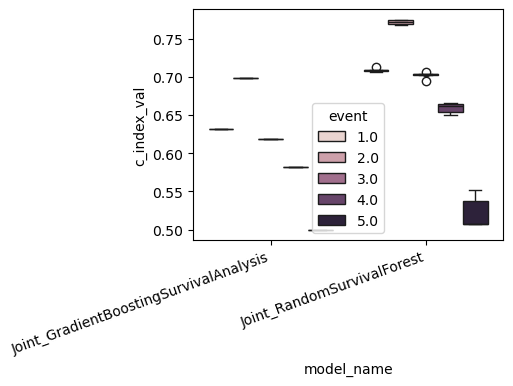

In [14]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.boxplot(
    data=df_metrics,
    x='model_name',
    y='c_index_val',
    hue='event',
    ax=ax,
)
plt.xticks(rotation=20, ha='right')


In [15]:
n_curves_per_model = [len(i) for i in surv_funcs.values()]

n_curves_per_model = n_curves_per_model[0]

In [16]:
list(surv_funcs.keys())

['Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_10_event_5.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_20_event_5.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_seed_30_event_4.0',
 'Joint_GradientBoostingSurvivalAnalysis_more_g_